In [1]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
from functools import partial
import numpy as np
import s3fs
s3 = s3fs.S3FileSystem(anon=True)

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
imsr = pd.read_csv("/home/jovyan/Preparedness_level/IMRS_from_pub/gacc_activity.csv")
wf = pd.read_csv("/home/jovyan/Preparedness_level/IMRS_from_pub/wildfire_activity.csv")

coerced_series = pd.to_numeric(wf['fire_size'], errors='coerce')

# Filter the original DataFrame to show only the rows that became NaN
non_numeric_df = wf[coerced_series.isna()].fire_size.unique()

print(non_numeric_df)

['NR' nan '---']


Text(0.5, 0, 'Percent Contrained')

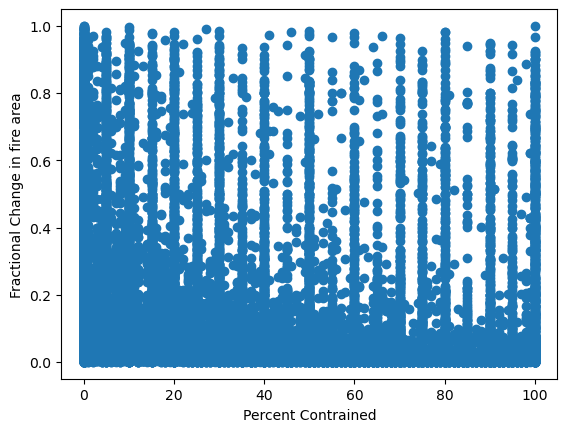

In [3]:
fire_size = pd.to_numeric(wf['fire_size'], errors='coerce')

fire_size_change = pd.to_numeric(wf['fire_size_change'], errors='coerce')
percent_containment = pd.to_numeric(wf['percent_containment'], errors='coerce')

mask = (~fire_size_change.isna()) & (~percent_containment.isna()) & (~fire_size.isna()) & (fire_size_change > 0) & (fire_size_change <= fire_size) & (fire_size > 988.4) ## Assuming in acers, this is 4 km^2


plt.scatter(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float") )
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contrained")

Text(0.5, 0, 'Percent Contained')

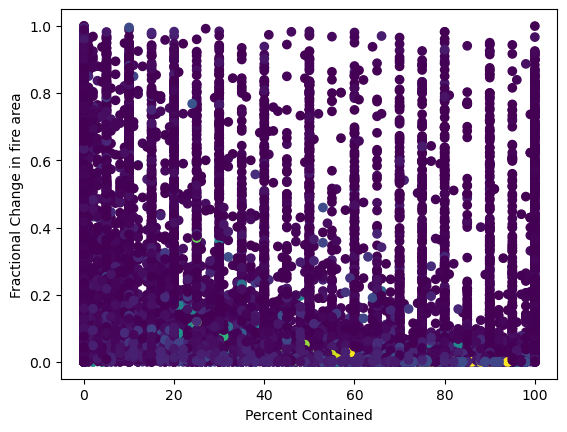

In [4]:
plt.scatter(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float"), c = wf[mask].fire_size.astype("float"))
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contained")

Text(0.5, 1.0, 'IMSR - Fire growth fnx of Containment')

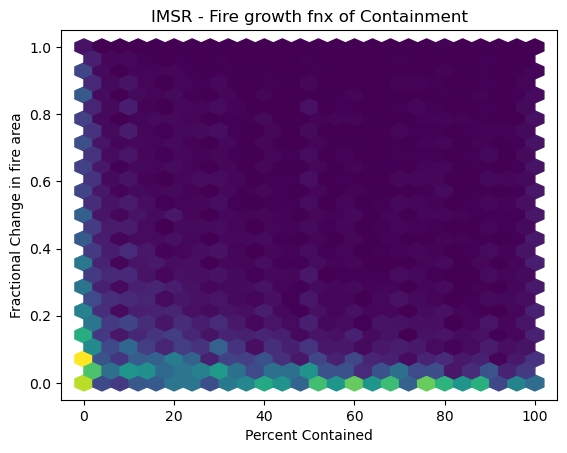

In [5]:
plt.hexbin(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float"), gridsize = 25)
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contained")
plt.title("IMSR - Fire growth fnx of Containment")

In [6]:

### Note: Zeb's data isn't appropriate for comparision with the IMSR data because he doesn't preserve the fireline and fireline length numbers for the fire spread increments -- which means I only have that only have that info for the LAST active fire increment. Need to recrete on my own. 


fires = pd.read_parquet("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/sigdeltas_Tess.parq")
subset_fires = gpd.read_parquet("s3://maap-ops-workspace/shared/zbecker/YANG/large_feds_faf_double_matched.parq")
subset_fires = subset_fires.to_crs(4326)

subset_fires["centroid"] = subset_fires.to_crs(4326).centroid
fires["UfireID"] = fires.mergeid.astype("int").astype("str") + "_" + fires.year.astype("str")
subset_fires["UfireID"] = subset_fires.mergeid.astype("str") + "_" + subset_fires.year.astype("str")
subset_fires["polygon"] = subset_fires.geometry
fires = fires[fires.UfireID.isin(subset_fires[subset_fires.intersectsMTBS == True].UfireID)]
fname = pd.read_csv("s3://maap-ops-workspace/shared/zbecker/Eli_MTBS_vs_FEDS/v6_output.csv")
fires["t"] = pd.to_datetime(fires['t'])

fires = fires.merge(subset_fires[['UfireID', 'centroid', 'polygon', 'fperim',	'flinelen', 'farea', 't']], on = ['UfireID', 't'] )
fires_final = fires.merge(subset_fires[['UfireID', 'centroid', 'polygon', 'fperim',	'flinelen', 'farea', 't']], on = ['UfireID', 't'] )
fires = gpd.GeoDataFrame(fires, geometry = 'polygon')

def get_st_sp_fire(df, days_after = 7):
    df.loc[:, "start_time"] = df.t.min()
    df.loc[:, "end_time"] = df.t.max()
    df.loc[:, "end_time_plus"] = df.t.astype("datetime64[ns]").max()  + datetime.timedelta(days = days_after)
    df = df.loc[df.t == df.t.max(), :]
    return(df)
    
fires_sm = fires.groupby("UfireID").apply(get_st_sp_fire).reset_index(drop = True)
fires_sm["stable_index"] = fires_sm.index

In [7]:
# plt.hexbin(((1 - ((fires['flinelen'])/fires['fperim'])) * 100 ), fires['area_growth_at_t_km2'].astype("float")/fires['farea'].astype("float"), gridsize = 25)
# plt.ylabel("Fractional Change in fire area")
# plt.xlabel("1 - percent fireline  for final growth increment")
# plt.title("FEDS - Fire growth fnx of % fireline")

In [8]:
### Why fractional change so big????

### Why inverse??? 


## What's up with this???

### you only have the farea and flinelen for the final growth increment in this current setup. :( 

# Recreating the IMSR % contained using FEDS data


In [19]:
## Reading in an example year from allfires objects

def corrected_farea_diff(df):
    df.loc[: ,"farea_diff"] = df.farea.diff()
    df.loc[df.t.astype('datetime64[ns]') == df.t.astype('datetime64[ns]').min(), "farea_diff"] = df.loc[df.t.astype('datetime64[ns]') == df.t.astype('datetime64[ns]').min(), "farea"]
    df["first_obs"] = False
    df.loc[df.t.astype('datetime64[ns]') == df.t.astype('datetime64[ns]').min(), "first_obs"] = True
    return(df)

def correct_gaps_in_timeseries(df):
    ### put in rows for missing 12-hour timesteps. \
    df["t"] = pd.to_datetime(df['t'])
    min_time = df['t'].min()
    max_time = df['t'].max()
    time_steps = pd.date_range(start=min_time, end=max_time, freq='12h')
    df_new_times = pd.DataFrame({'t': time_steps})
    df_merged = pd.merge(df_new_times, df, on='t', how='left')
    df_sub = df_merged[['mergeid', 't', 'farea', 'fperim', 'flinelen']].ffill()
    df_merged.loc[:,"farea"] = df_sub.farea
    df_merged.loc[:,'fperim'] = df_sub.fperim
    df_merged.loc[:,'flinelen'] = df_sub.flinelen
    # df_merged.loc[df_merged.n_newpixels == 0, 'flinelen'] = 0
    # df_merged.loc[df_merged.n_newpixels == 0, 'isactive'] = np.nan
    # df_merged.loc[df_merged.n_newpixels == 0,  'pixden'] = np.nan
    # df_merged.loc[df_merged.n_newpixels == 0,  'meanFRP'] = np.nan
    return(df_merged)


def read_in_allfires(years):
    print(f"combining {len(years)}. Careful, I think a year is ~ 1 GB")
    dfs = []
    for y in years:
        yr = str(y)
        #path = f's3://maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-v3/ArchiveCONUS{yr}/{yr}/CombinedLargefire/{yr}1231PM/lf_perimeter.fgb'
        path = f's3://maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-v3/ArchiveCONUS{yr}/{yr}/allfires_{yr}1231_PM.parq'
        feds_21 = gpd.read_file(path)
        feds_21 = feds_21.groupby("mergeid").apply(correct_gaps_in_timeseries).reset_index(drop = True)
        print(years)
        print(feds_21.columns)
        feds_21 = feds_21.groupby("mergeid").apply(corrected_farea_diff).reset_index(drop = True)
        feds_21["UfireID"] = feds_21.mergeid.astype("int").astype("str") + "_" + feds_21.t.dt.year.astype("str")
        dfs.append(feds_21)
    all_yrs = pd.concat(dfs, ignore_index=True)

    print(f" AFAIK I am not subsetting by GACC or ecoregion, so I am including the kansas megafires.")
    return(all_yrs)

years = [ "2021"]

feds_21 = read_in_allfires(years)
feds_21 = feds_21[feds_21.UfireID.isin(fires_sm.UfireID)] ## doing afterwards. 

combining 1. Careful, I think a year is ~ 1 GB
['2021']
Index(['t', 'mergeid', 'invalid', 'ftype', 'n_pixels', 'n_newpixels', 'farea',
       'fperim', 'flinelen', 'duration', 'pixden', 'meanFRP', 't_st', 't_ed',
       'fireID', 'geometry'],
      dtype='object')
 AFAIK I am not subsetting by GACC or ecoregion, so I am including the kansas megafires.


In [20]:
# feds_21 = gpd.read_file("s3://maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-v3/ArchiveCONUS2021/2021/CombinedLargefire/20211231PM/lf_perimeter.fgb")

#feds_21 = gpd.read_file("s3://maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-v3/ArchiveCONUS2021/2021/allfires_20211231_PM.parq")
    
# feds_21 = feds_21.groupby("mergeid").apply(correct_gaps_in_timeseries).reset_index(drop = True)
# feds_21 = feds_21.groupby("mergeid").apply(corrected_farea_diff).reset_index(drop = True)
# feds_21["UfireID"] = feds_21.mergeid.astype("int").astype("str") + "_" + feds_21.t.dt.year.astype("str")
# feds_21 = feds_21[feds_21.UfireID.isin(fires_sm.UfireID)]

# print(f" AFAIK I am not subsetting by GACC or ecoregion, so I am including the kansas megafires.")

Text(0.5, 0.98, 'N of 423, with 266 unique fires')

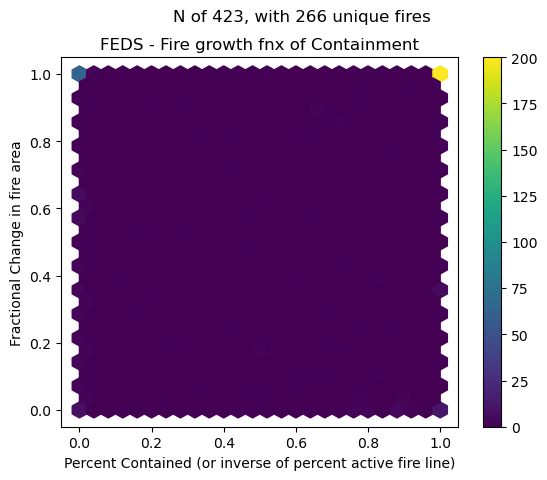

In [21]:

mask_feds = (~feds_21.fperim.isna()) & (~feds_21.flinelen.isna()) & (~feds_21.farea.isna()) & (feds_21.farea_diff > 0) & (feds_21.farea_diff <= feds_21.farea) & (feds_21.n_newpixels > 0 )
 


plt.hexbin((1 - (feds_21[mask_feds].flinelen.astype("float") / feds_21[mask_feds].fperim.astype("float"))), feds_21[mask_feds].farea_diff.astype("float")/feds_21[mask_feds].farea, gridsize = 25)
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contained (or inverse of percent active fire line)")
plt.colorbar()
plt.title("FEDS - Fire growth fnx of Containment")
plt.suptitle(f"N of {len(feds_21[mask_feds])}, with {len(feds_21[mask_feds].UfireID.unique())} unique fires")

Text(0.5, 1.0, 'IMSR - Fire growth fnx of Containment')

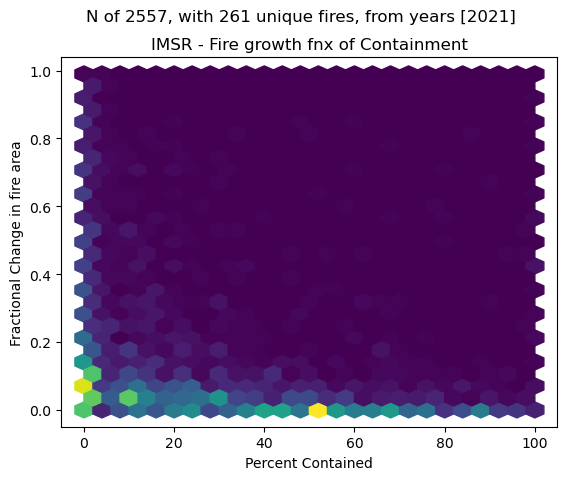

In [12]:
mask = (~fire_size_change.isna()) & (~percent_containment.isna()) & (~fire_size.isna()) & (fire_size_change > 0) & (fire_size_change <= fire_size) & (fire_size > 988.4) & (wf.imsr_date.astype("datetime64[ns]").dt.year.astype("str").isin(years))## Assuming in acers, this is 4 km^2



plt.hexbin(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float"), gridsize = 25)
plt.ylabel("Fractional Change in fire area")
plt.xlabel("Percent Contained")
plt.suptitle(f"N of {len(wf[mask])}, with {len(wf[mask].fire_name.unique())} unique fires, from years {wf[mask].imsr_date.astype("datetime64[ns]").dt.year.unique()}")
plt.title("IMSR - Fire growth fnx of Containment")
plt.colorbar()

In [ ]:
# plt.(wf[mask].percent_containment.astype("float"), wf[mask].fire_size_change.astype("float")/wf[mask].fire_size.astype("float"))
# plt.ylabel("Fractional Change in fire area")
# plt.xlabel("Percent Contained")
# plt.suptitle(f"N of {len(wf[mask])}, with {len(wf[mask].fire_name.unique())} unique fires, from years {wf[mask].imsr_date.astype("datetime64[ns]").dt.year.unique()}")
# plt.title("IMSR - Fire growth fnx of Containment")
# plt.colorbar()